In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_parquet(
    "/home/ed/Desktop/TS-Forecasting/data/yellow_tripdata_2026-01.parquet"
)

In [29]:
print("="*80)
print("YELLOW TAXI DATASET")
print("="*80)


print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMemory Usage MB")
print(round(df.memory_usage(deep=True).sum()/1024**2,2))

YELLOW TAXI DATASET

Shape
(3724889, 20)

Columns
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Data Types
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                 


Missing Values
                       Missing  Percent
passenger_count        1088058    29.21
congestion_surcharge   1088058    29.21
store_and_fwd_flag     1088058    29.21
RatecodeID             1088058    29.21
Airport_fee            1088058    29.21
tpep_dropoff_datetime        0     0.00
VendorID                     0     0.00
tpep_pickup_datetime         0     0.00
DOLocationID                 0     0.00
payment_type                 0     0.00
trip_distance                0     0.00
PULocationID                 0     0.00
extra                        0     0.00
fare_amount                  0     0.00
mta_tax                      0     0.00
tip_amount                   0     0.00
improvement_surcharge        0     0.00
tolls_amount                 0     0.00
total_amount                 0     0.00
cbd_congestion_fee           0     0.00


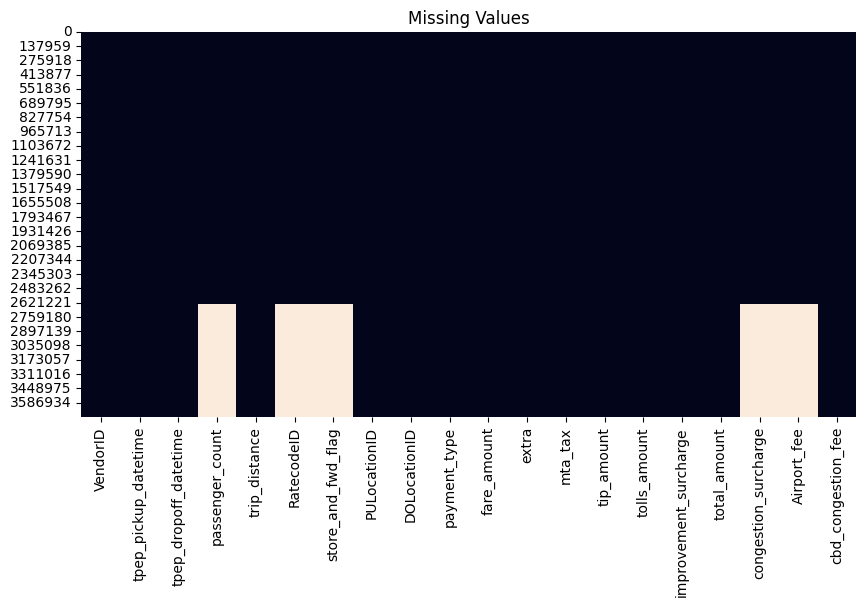

In [30]:
# -------------------------
# MISSING VALUES
# -------------------------

missing = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Percent":round(df.isnull().mean()*100,2)
})

print("\nMissing Values")
print(missing.sort_values(
    "Percent",
    ascending=False
))

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [31]:
# -------------------------
# DUPLICATES
# -------------------------

print("\nDuplicates")
print(df.duplicated().sum())



Duplicates
0


In [32]:

# -------------------------
# DESCRIPTIVE STATS
# -------------------------

print(df.describe())


           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  3.724889e+06                     3724889                     3724889   
mean   1.873598e+00  2026-01-17 01:44:52.106518  2026-01-17 02:02:03.696138   
min    1.000000e+00         2025-12-31 23:57:29         2025-12-31 23:57:32   
25%    2.000000e+00         2026-01-09 17:51:59         2026-01-09 18:08:47   
50%    2.000000e+00         2026-01-16 21:20:56         2026-01-16 21:36:14   
75%    2.000000e+00         2026-01-24 07:25:11         2026-01-24 07:40:22   
max    7.000000e+00         2026-02-01 00:45:01         2026-02-01 23:35:31   
std    7.014583e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     2.636831e+06   3.724889e+06  2.636831e+06  3.724889e+06   
mean      1.256271e+00   6.455647e+00  5.218853e+00  1.614372e+02   
min       0.000000e+00   0.000000e+00  1.000000e+00  1.000000e+00   
25%       1.

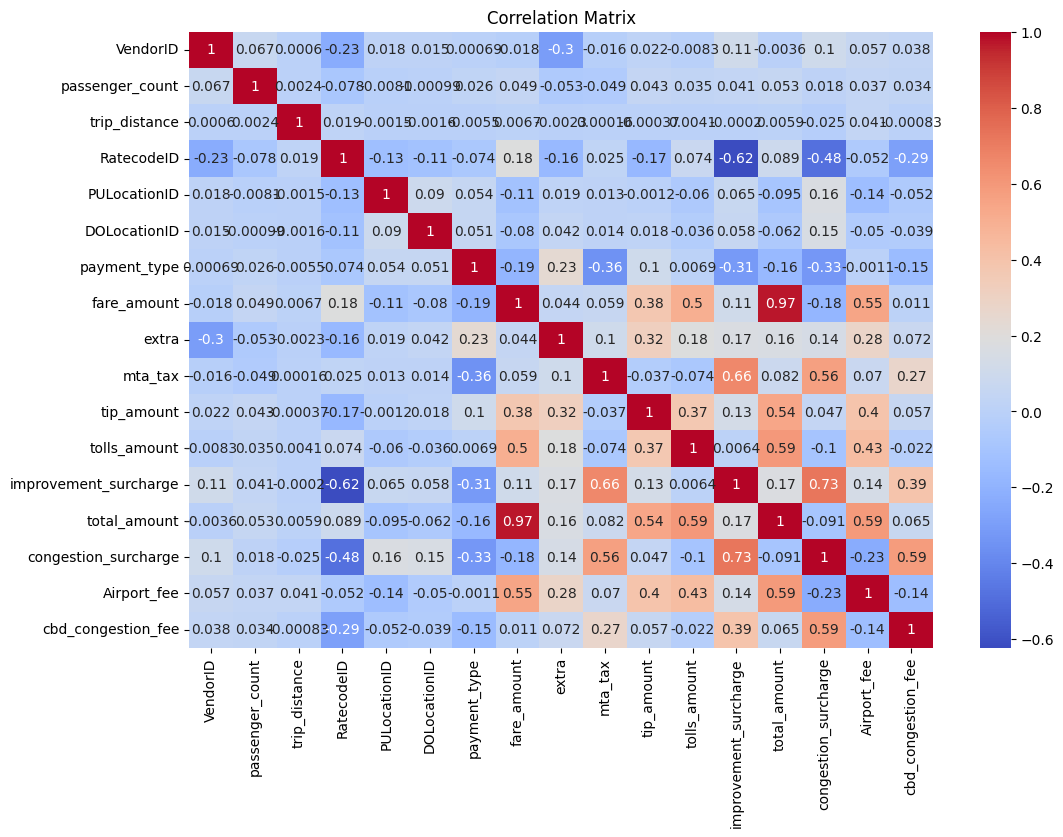

In [33]:
# -------------------------
# CORRELATION
# -------------------------

numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()


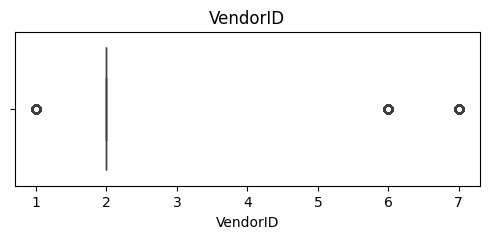

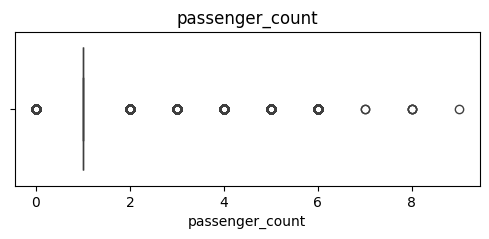

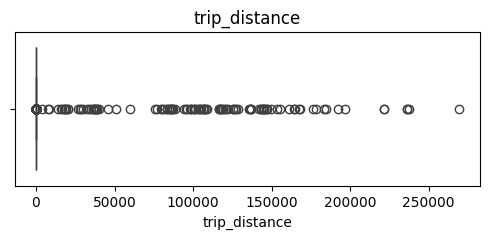

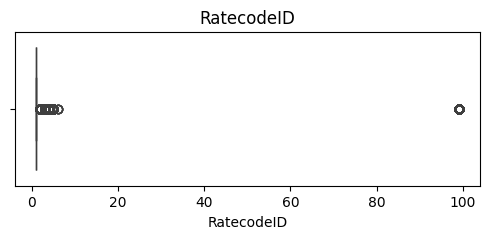

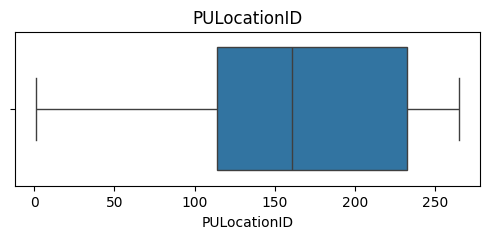

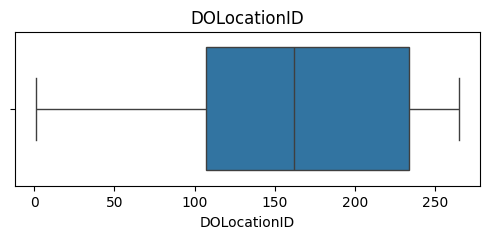

In [34]:

# -------------------------
# OUTLIERS
# -------------------------

for col in numeric_cols.columns[:6]:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()


In [35]:
# -------------------------
# TIME COVERAGE
# -------------------------

print(
    "\nPickup Date Range:"
)

print(
    df['tpep_pickup_datetime'].min(),
    "to",
    df['tpep_pickup_datetime'].max()
)


Pickup Date Range:
2025-12-31 23:57:29 to 2026-02-01 00:45:01



Unique Pickup Zones:
262


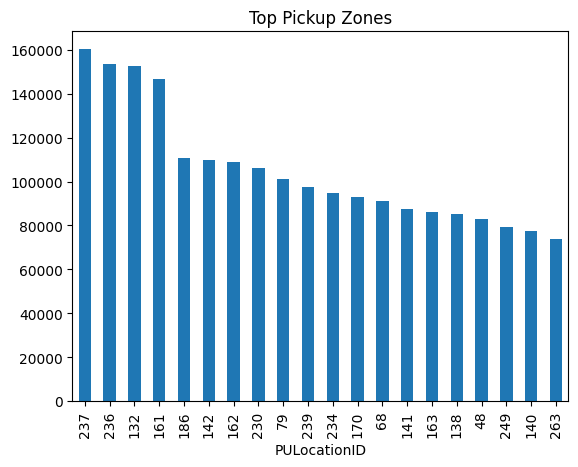

In [36]:
# -------------------------
# ZONE COVERAGE
# -------------------------

print(
    "\nUnique Pickup Zones:"
)

print(
    df['PULocationID'].nunique()
)

df['PULocationID'].value_counts()\
.head(20)\
.plot(kind='bar')

plt.title(
    'Top Pickup Zones'
)

plt.show()

In [37]:
# -------------------------
# DEMAND CREATION
# -------------------------

df['hour_bucket'] = (
    df['tpep_pickup_datetime']
    .dt.floor('h')
)

hourly_demand = (
    df.groupby(
        ['hour_bucket','PULocationID']
    )
    .size()
    .reset_index(
        name='demand'
    )
)

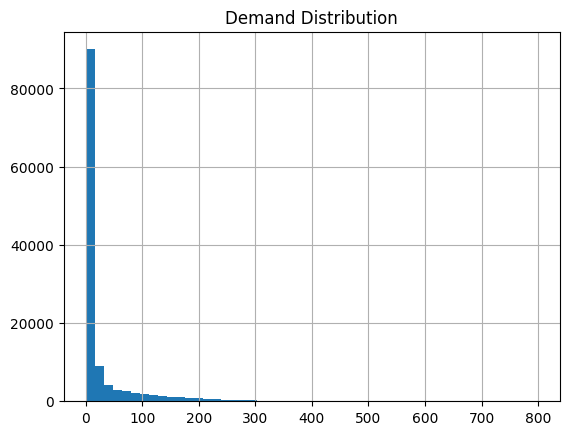

In [38]:
# -------------------------
# DEMAND EDA
# -------------------------

hourly_demand['demand'].hist(
    bins=50
)

plt.title(
    "Demand Distribution"
)

plt.show()

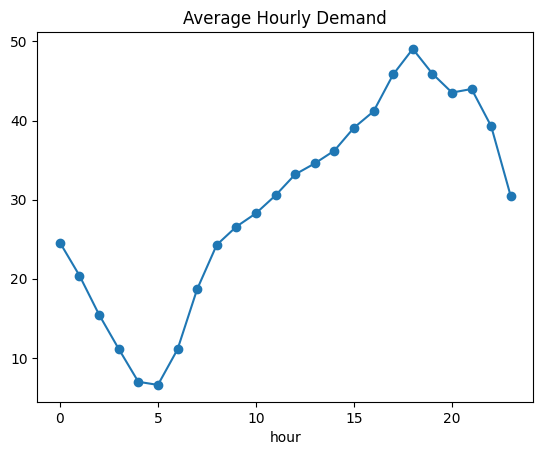

In [39]:
# Hourly Pattern

hourly_demand['hour'] = (
    hourly_demand['hour_bucket']
    .dt.hour
)

hourly_pattern = (
    hourly_demand
    .groupby('hour')['demand']
    .mean()
)

hourly_pattern.plot(
    marker='o'
)

plt.title(
    "Average Hourly Demand"
)

plt.show()

In [43]:
hourly_demand['day_of_week'] = (
    hourly_demand['hour_bucket']
    .dt.dayofweek
)
hourly_demand

,hour_bucket,PULocationID,demand,hour,day_of_week
0,2025-12-31 23:00:00,113,1,23,2
1,2025-12-31 23:00:00,132,3,23,2
2,2025-12-31 23:00:00,163,1,23,2
3,2025-12-31 23:00:00,164,1,23,2
4,2026-01-01 00:00:00,3,2,0,3
...,...,...,...,...,...
123598,2026-01-31 23:00:00,261,29,23,5
123599,2026-01-31 23:00:00,262,59,23,5
123600,2026-01-31 23:00:00,263,175,23,5
123601,2026-01-31 23:00:00,264,5,23,5


In [45]:
hourly_demand['month'] = (
    hourly_demand['hour_bucket']
    .dt.month
)
hourly_demand

,hour_bucket,PULocationID,demand,hour,day_of_week,month
0,2025-12-31 23:00:00,113,1,23,2,12
1,2025-12-31 23:00:00,132,3,23,2,12
2,2025-12-31 23:00:00,163,1,23,2,12
3,2025-12-31 23:00:00,164,1,23,2,12
4,2026-01-01 00:00:00,3,2,0,3,1
...,...,...,...,...,...,...
123598,2026-01-31 23:00:00,261,29,23,5,1
123599,2026-01-31 23:00:00,262,59,23,5,1
123600,2026-01-31 23:00:00,263,175,23,5,1
123601,2026-01-31 23:00:00,264,5,23,5,1


In [46]:
hourly_demand['is_weekend'] = (
    hourly_demand['day_of_week']>=5
).astype(int)
hourly_demand

,hour_bucket,PULocationID,demand,hour,day_of_week,month,is_weekend
0,2025-12-31 23:00:00,113,1,23,2,12,0
1,2025-12-31 23:00:00,132,3,23,2,12,0
2,2025-12-31 23:00:00,163,1,23,2,12,0
3,2025-12-31 23:00:00,164,1,23,2,12,0
4,2026-01-01 00:00:00,3,2,0,3,1,0
...,...,...,...,...,...,...,...
123598,2026-01-31 23:00:00,261,29,23,5,1,1
123599,2026-01-31 23:00:00,262,59,23,5,1,1
123600,2026-01-31 23:00:00,263,175,23,5,1,1
123601,2026-01-31 23:00:00,264,5,23,5,1,1


In [48]:
hourly_demand = hourly_demand.sort_values(
    ['PULocationID','hour_bucket']
)
hourly_demand

,hour_bucket,PULocationID,demand,hour,day_of_week,month,is_weekend
426,2026-01-01 02:00:00,1,1,2,3,1,0
839,2026-01-01 04:00:00,1,3,4,3,1,0
1021,2026-01-01 05:00:00,1,5,5,3,1,0
1200,2026-01-01 06:00:00,1,2,6,3,1,0
1395,2026-01-01 07:00:00,1,2,7,3,1,0
...,...,...,...,...,...,...,...
122324,2026-01-31 16:00:00,265,3,16,5,1,1
122503,2026-01-31 17:00:00,265,2,17,5,1,1
123064,2026-01-31 20:00:00,265,1,20,5,1,1
123239,2026-01-31 21:00:00,265,1,21,5,1,1


In [51]:
hourly_demand['lag_1'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .shift(1)
)
hourly_demand['lag_1'] 

426       NaN
839       1.0
1021      3.0
1200      5.0
1395      2.0
         ... 
122324    2.0
122503    3.0
123064    2.0
123239    1.0
123418    1.0
Name: lag_1, Length: 123603, dtype: float64

In [53]:
hourly_demand['lag_24'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .shift(24)
)
hourly_demand['lag_24']

426       NaN
839       NaN
1021      NaN
1200      NaN
1395      NaN
         ... 
122324    6.0
122503    3.0
123064    3.0
123239    3.0
123418    1.0
Name: lag_24, Length: 123603, dtype: float64

In [55]:

hourly_demand['rolling_mean_24'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(24)
         .mean()
    )
)

print(hourly_demand.sample(10))

               hour_bucket  PULocationID  demand  hour  day_of_week  month  \
110527 2026-01-28 22:00:00            13      40    22            2      1   
80709  2026-01-21 10:00:00           217       1    10            2      1   
23845  2026-01-07 00:00:00           133       1     0            2      1   
22587  2026-01-06 16:00:00            75      84    16            1      1   
27398  2026-01-07 22:00:00            41      21    22            2      1   
46736  2026-01-12 19:00:00           158      52    19            0      1   
63454  2026-01-17 01:00:00            41      18     1            5      1   
31792  2026-01-09 01:00:00            70       2     1            4      1   
22548  2026-01-06 16:00:00            17       5    16            1      1   
111110 2026-01-29 02:00:00            22       1     2            3      1   

        is_weekend  lag_1  lag_24  rolling_mean_24  
110527           0   78.0    73.0        47.916667  
80709            0    1.0     1.0  